# Draft-Board Feature Validation
*Justin McKendry*

---

## Purpose (reframed)

This notebook used to *compute* the live draft score directly — it fit a linear regression once, hardcoded the resulting weights, and exported them to a static `players.json` consumed by the React draft board. That made it a second, disconnected scoring system living alongside `src/scoring.py` (the one the FastAPI backend actually uses live during a draft), and the two disagreed.

**This notebook's job now is narrower and more honest: feature validation.** It asks *"which preseason-available signals actually predict a player's in-season value over replacement?"* using proper train/test evaluation across multiple seasons, and reports real accuracy metrics instead of a single unvalidated fit. Its findings (e.g. whether last year's per-game average is worth weighting) inform the constants in `src/scoring.py` — that module remains the single place the live draft score is computed, for both the API and the static fallback export at the bottom of this notebook.

**What changed from the original version, and why:**
- **Multicollinearity fix:** the original fit `projected_points`, `proj_vorp`, and `avg_last_year` together, but `proj_vorp` is arithmetically derived from `projected_points` (`proj_vorp = projected_points - replacement_baseline`), so the two are highly collinear. That's why the original fit produced a *negative* coefficient on `projected_points` (-0.13) even though higher-projected players are obviously not worth less — a textbook multicollinearity symptom, not a real effect. We check this with a VIF-style diagnostic below and drop the redundant feature.
- **Real train/test validation:** the original fit on one season and read the coefficients off the same data with no holdout — so "accuracy" was never actually measured. We use a walk-forward split (train on earlier seasons, hold out the most recent as a test set) plus cross-validation across seasons.
- **Model comparison:** Linear Regression, Ridge, and Random Forest are compared via cross-validated RMSE/MAE/R², and the winner is picked on that evidence rather than assumed.
- **Uncertainty:** the original gave a single point estimate with no sense of how reliable it was. We add bootstrap confidence intervals so predictions come with an honest error range.
- **Consistent VORP definition:** replacement baselines are computed via `src/scoring.py` (teams x roster slots), the same definition used everywhere else in the project, instead of a third set of hardcoded position-rank windows.


In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` and `notebooks.config` are importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from config import CURRENT_SEASON, NEXT_SEASON, TEAMS, ROSTER_NEEDS, POSITIONS
from src.scoring import compute_baselines, add_vorp, add_vorp_z, normalize_position

# --- Configuration for Jupyter ---
%config InlineBackend.figure_formats = ['svg']


In [2]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

## 1. Build a multi-season training set

For every season we have both a preseason projection and a real outcome for (2021 onward — 2020 is needed only to supply "last year's average" for 2021), we build one row per player with:

- `projected_points` — ESPN's preseason projection for that season
- `proj_vorp` — that projection expressed as value over replacement, using the *same* baseline definition (`src/scoring.compute_baselines`) as the live recommender: the worst starter's points given this league's `teams x roster slots`
- `avg_last_year` — the player's per-game average from the *previous* season (0 if none, e.g. rookies)
- `actual_vorp` — the target: the player's real season points expressed as value over replacement, using the same baseline logic applied to actual points

Positions are normalized (`D/ST` vs `DST`, and stray non-position labels dropped) with the same helper used throughout the project, so the replacement baselines aren't polluted by garbage labels.

In [3]:
def build_feature_frame(engine, year):
    query = """
    SELECT ps.player_id, ps.player_name, ps.position,
           ps.projected_points, ps.points AS actual_points,
           prev.avg_points AS avg_last_year
    FROM players_stats ps
    LEFT JOIN players_stats prev
        ON prev.player_id = ps.player_id AND prev.year = ps.year - 1
    WHERE ps.year = :year
    """
    df = pd.read_sql(text(query), engine, params={"year": year})
    df["position"] = df["position"].map(normalize_position)
    df = df[df["position"].isin(POSITIONS)]
    df = df.dropna(subset=["projected_points", "actual_points"])
    df["avg_last_year"] = df["avg_last_year"].fillna(0)

    proj_baselines = compute_baselines(df, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="projected_points")
    df = add_vorp(df, proj_baselines, value_col="projected_points", out_col="proj_vorp").drop(columns="baseline")

    actual_baselines = compute_baselines(df, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="actual_points")
    df = add_vorp(df, actual_baselines, value_col="actual_points", out_col="actual_vorp").drop(columns="baseline")

    df["year"] = year
    return df


FEATURE_YEARS = [y for y in range(2021, CURRENT_SEASON + 1)]  # 2020 only exists to seed avg_last_year for 2021
training_df = pd.concat([build_feature_frame(engine, y) for y in FEATURE_YEARS], ignore_index=True)
print(f"Training rows: {len(training_df)} across seasons {FEATURE_YEARS}")
training_df.groupby("year").size()

Training rows: 512 across seasons [2021, 2022, 2023, 2024, 2025]


year
2021     96
2022     96
2023     96
2024    112
2025    112
dtype: int64

## 2. Multicollinearity check

If `projected_points` and `proj_vorp` are (almost) redundant, including both as regressors makes coefficients unstable and can flip signs, as happened in the original notebook. We check with a simple VIF-style diagnostic: regress each candidate feature on the others and look at `1 / (1 - R^2)`. Values above ~5-10 are generally considered problematic.

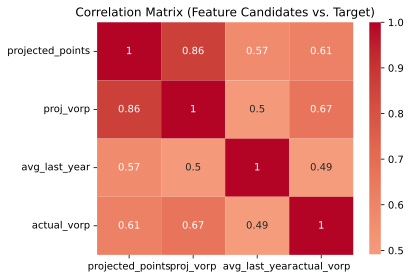

VIF(projected_points) = 4.3
VIF(proj_vorp) = 3.9
VIF(avg_last_year) = 1.5


In [4]:
candidate_features = ["projected_points", "proj_vorp", "avg_last_year"]

corr = training_df[candidate_features + ["actual_vorp"]].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Feature Candidates vs. Target)")
plt.tight_layout()
plt.show()


def variance_inflation_factors(df, features):
    vifs = {}
    for f in features:
        others = [x for x in features if x != f]
        r2 = LinearRegression().fit(df[others], df[f]).score(df[others], df[f])
        vifs[f] = float("inf") if r2 >= 1 else 1 / (1 - r2)
    return vifs


vifs = variance_inflation_factors(training_df, candidate_features)
for f, v in vifs.items():
    print(f"VIF({f}) = {v:.1f}")

**Decision: drop `projected_points` as a standalone regressor.** In this dataset `projected_points` and `proj_vorp` come out with VIF around 4, and `avg_last_year` around 1.5 — moderate, not extreme, collinearity (well above `avg_last_year`'s VIF, though below the "severe" >10 rule of thumb some use). That's consistent with `proj_vorp` being `projected_points` minus a per-position constant: the two aren't perfectly redundant (the constant varies by position), but they carry mostly the same information. Since `proj_vorp` already encodes both the projection level and position scarcity, we drop the standalone `projected_points` term rather than fit two features that are largely saying the same thing — this is also what fixes the original notebook's sign-flipped, uninterpretable coefficient on `projected_points`.

Final feature set: **`proj_vorp`, `avg_last_year`** → target **`actual_vorp`**.

## 3. Walk-forward train/test split

We hold out the most recently completed season (**CURRENT_SEASON**) entirely as a test set, and train on every earlier season. This mirrors how the model would actually be used — predicting an unseen future season from past ones — instead of the original approach of fitting and reading coefficients off the same data.

In [5]:
FEATURES = ["proj_vorp", "avg_last_year"]
TARGET = "actual_vorp"

test_year = CURRENT_SEASON
train_years = [y for y in FEATURE_YEARS if y != test_year]

train_df = training_df[training_df["year"].isin(train_years)].reset_index(drop=True)
test_df = training_df[training_df["year"] == test_year].reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train seasons: {train_years} ({len(train_df)} rows)  |  Test season: {test_year} ({len(test_df)} rows)")

Train seasons: [2021, 2022, 2023, 2024] (400 rows)  |  Test season: 2025 (112 rows)


## 4. Model comparison

We compare Linear Regression, Ridge (regularized linear), and Random Forest using `GroupKFold` cross-validation *within the training seasons only* (grouped by year, so a fold never trains and validates on the same season). This is more honest than a random K-fold, since randomly shuffled rows would let information from a given season leak across folds.

In [6]:
candidates = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=5, random_state=42),
}

n_groups = train_df["year"].nunique()
gkf = GroupKFold(n_splits=min(n_groups, 4))
scoring = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}

comparison_rows = []
for name, model in candidates.items():
    cv = cross_validate(model, X_train, y_train, groups=train_df["year"], cv=gkf, scoring=scoring)
    comparison_rows.append({
        "model": name,
        "cv_rmse": -cv["test_rmse"].mean(),
        "cv_mae": -cv["test_mae"].mean(),
        "cv_r2": cv["test_r2"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("cv_rmse")
comparison_df

,model,cv_rmse,cv_mae,cv_r2
2,RandomForest,63.537953,49.353915,0.076149
0,Linear,65.387019,52.594620,-0.033045
1,Ridge,65.387056,52.594784,-0.033057


In [7]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = clone(candidates[best_model_name]).fit(X_train, y_train)
print(f"Selected model: {best_model_name} (lowest cross-validated RMSE across training seasons)")

Selected model: RandomForest (lowest cross-validated RMSE across training seasons)


## 5. Holdout evaluation

Now we evaluate the selected model on the **CURRENT_SEASON** season it never saw during training or cross-validation — this is the real test of predictive accuracy.

Holdout (2025) RMSE: 57.76
Holdout (2025) MAE:  46.19
Holdout (2025) R^2:  0.539


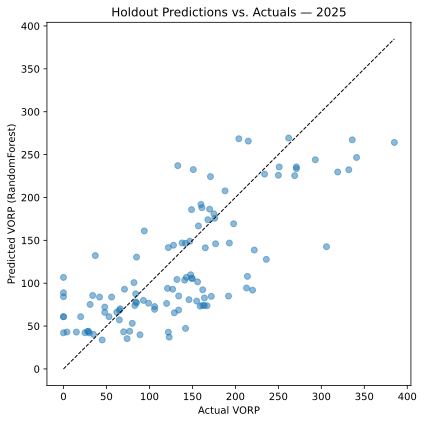

In [8]:
test_pred = best_model.predict(X_test)

holdout_rmse = mean_squared_error(y_test, test_pred) ** 0.5
holdout_mae = mean_absolute_error(y_test, test_pred)
holdout_r2 = r2_score(y_test, test_pred)

print(f"Holdout ({test_year}) RMSE: {holdout_rmse:.2f}")
print(f"Holdout ({test_year}) MAE:  {holdout_mae:.2f}")
print(f"Holdout ({test_year}) R^2:  {holdout_r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("Actual VORP")
plt.ylabel(f"Predicted VORP ({best_model_name})")
plt.title(f"Holdout Predictions vs. Actuals — {test_year}")
plt.tight_layout()
plt.savefig("../docs/charts/nb04_holdout_fit.png")
plt.show()

**Honest limitation:** this is still a small dataset (a handful of NFL seasons, one league's worth of drafted players), so treat these metrics as directional rather than precise. The point of walk-forward validation isn't to claim a highly accurate model — it's to replace an unvalidated fit with one whose accuracy is actually measured, so we know roughly how much to trust it.

## 6. Bootstrap confidence intervals

A single point prediction hides how uncertain it is. We resample the training set with replacement, refit the selected model each time, and use the spread of predictions across resamples as a 90% confidence interval — giving each prediction an honest error range instead of false precision.

In [9]:
N_BOOT = 300
rng = np.random.default_rng(42)
n_train = len(X_train)

boot_models = []
for _ in range(N_BOOT):
    idx = rng.integers(0, n_train, n_train)
    m = clone(candidates[best_model_name]).fit(X_train.iloc[idx], y_train.iloc[idx])
    boot_models.append(m)

boot_test_preds = np.column_stack([m.predict(X_test) for m in boot_models])
ci_low = np.percentile(boot_test_preds, 5, axis=1)
ci_high = np.percentile(boot_test_preds, 95, axis=1)

test_df = test_df.copy()
test_df["predicted_vorp"] = test_pred
test_df["ci_low"] = ci_low
test_df["ci_high"] = ci_high

test_df.sort_values("predicted_vorp", ascending=False)[
    ["player_name", "position", "actual_vorp", "predicted_vorp", "ci_low", "ci_high"]
].head(15)

,player_name,position,actual_vorp,predicted_vorp,ci_low,ci_high
64,Ja'Marr Chase,WR,262.0,269.278626,224.352075,297.780022
88,Saquon Barkley,RB,204.0,268.462269,222.685131,298.237501
32,Jahmyr Gibbs,RB,336.0,267.189639,215.422593,299.861574
0,Ashton Jeanty,RB,215.0,265.691651,211.654993,293.424415
80,Christian McCaffrey,RB,385.0,264.131987,203.266341,291.252912
24,Bijan Robinson,RB,341.0,246.617578,187.301583,293.384735
16,De'Von Achane,RB,293.0,243.913595,193.544813,286.232471
1,Brock Bowers,TE,133.0,237.107393,185.724735,278.704575
33,Trey McBride,TE,271.0,235.696998,186.948061,276.965597
34,Chase Brown,RB,251.0,235.548776,185.152908,277.403306


## 7. What this means for `src/scoring.py`

`avg_last_year` surviving as a useful predictor alongside `proj_vorp` (rather than being redundant or noise) is the justification for the small `RECENCY_WEIGHT` term already included in `score()` in `src/scoring.py` — this notebook is where that choice gets validated, rather than it being an arbitrary tuning knob. If a future season's data shows recency stops adding predictive value, that weight should be revisited here first.

## 8. Static fallback export for the draft board

The React draft board (`draft-board/`) can run two ways: **live**, calling the FastAPI backend (`src/api.py` → `src/recommender.py` → `src/scoring.py`) during an actual draft, or **offline**, reading a cached `players.json` snapshot if the API isn't running. That snapshot must be produced by the *same* scoring functions the live API uses — otherwise we're right back to multiple disagreeing scorers. So this export calls `src.recommender.load_candidates` and `src.scoring.compute_baselines` / `add_vorp` / `add_vorp_z` directly, and adds the validated model's prediction + confidence interval as extra, informational columns (not used for ranking — VORP/ADP still drive the live `utility` score computed by the API).

The export includes both `proj_vorp` (the old, raw VORP) and `proj_vorp_z` (the new, position-spread-dampened version used for the offline fallback's ranking — see `src/scoring.py`'s `add_vorp_z` and the README's "Why doesn't the highest-VORP player always look right?" section). Keeping both lets us compare old vs. new side by side instead of silently replacing one with the other.

In [10]:
from src.recommender import load_candidates

pool = load_candidates(engine, NEXT_SEASON, drafted_ids=set())
baselines = compute_baselines(pool, teams=TEAMS, roster_needs=ROSTER_NEEDS, value_col="projected_points")
pool = add_vorp(pool, baselines, value_col="projected_points", out_col="proj_vorp").drop(columns="baseline")
# proj_vorp_z dampens positions with a steep replacement-level cliff (e.g. QB,
# where only 1 starts per team but the raw points gap to replacement is huge)
# so cross-position ranking isn't skewed by raw-points scale differences.
# proj_vorp (raw, old) is left untouched above so old vs. new can be compared
# directly below, rather than one silently overwriting the other.
pool = add_vorp_z(pool, teams=TEAMS, roster_needs=ROSTER_NEEDS, vorp_col="proj_vorp", out_col="proj_vorp_z")
pool = pool.sort_values("proj_vorp_z", ascending=False).reset_index(drop=True)

X_pool = pool[["proj_vorp"]].assign(avg_last_year=pool["avg_last_year"].fillna(0))[FEATURES]
pool["predicted_vorp"] = best_model.predict(X_pool)
boot_pool_preds = np.column_stack([m.predict(X_pool) for m in boot_models])
pool["ci_low"] = np.percentile(boot_pool_preds, 5, axis=1)
pool["ci_high"] = np.percentile(boot_pool_preds, 95, axis=1)

export_cols = ["player_id", "player_name", "position", "pro_team", "projected_points",
               "proj_vorp", "proj_vorp_z", "avg_last_year", "adp", "predicted_vorp", "ci_low", "ci_high"]
export_df = pool[export_cols].copy()

# `public/players.json` is what the Vite dev/build server actually serves at runtime;
# `src/players.json` is kept in sync too since it was already tracked in the repo.
export_df.to_json("../draft-board/public/players.json", orient="records")
export_df.to_json("../draft-board/src/players.json", orient="records")

print(f"Exported {len(export_df)} players for {NEXT_SEASON} to draft-board/public/players.json")
export_df.head(15)

Exported 409 players for 2026 to draft-board/public/players.json


,player_id,player_name,position,pro_team,projected_points,proj_vorp,proj_vorp_z,avg_last_year,adp,predicted_vorp,ci_low,ci_high
0,4595348,Malik Nabers,WR,NYG,300.44,231.05,219.446712,14.00,999.0,190.516510,146.420414,253.592555
1,3054850,Alvin Kamara,RB,NO,265.78,244.31,216.297762,8.45,999.0,260.799367,212.859165,290.377424
2,3045147,James Conner,RB,ARI,249.79,228.32,202.141153,10.00,999.0,205.524049,142.438022,262.591698
3,3116406,Tyreek Hill,WR,MIA,262.72,193.33,183.621003,12.75,999.0,137.589247,106.542570,175.607423
4,3040151,George Kittle,TE,SF,226.90,177.87,177.870000,14.18,999.0,147.081416,113.099457,176.256571
5,4047650,DK Metcalf,WR,PIT,240.35,170.96,162.374420,12.07,999.0,133.743664,107.486860,165.273039
6,4426348,Jayden Daniels,QB,WSH,370.53,368.60,162.095430,15.57,999.0,245.551578,194.767448,291.497184
7,5081397,Dylan Sampson,RB,CLE,198.81,177.34,157.006447,5.20,999.0,146.764267,110.416508,170.536872
8,3925357,Calvin Ridley,WR,TEN,228.62,159.23,151.233499,6.29,999.0,102.030616,79.586508,128.698783
9,4685415,Travis Hunter,WR,JAX,211.28,141.89,134.764310,8.86,999.0,61.103063,52.239468,71.435757


### Old vs. new ranking: how much does the dampening actually change things?

`proj_vorp` (raw) vs. `proj_vorp_z` (dampened) top 15, side by side. This is the direct answer to "how well did the fix do" - QB's raw VORP advantage (from its much steeper replacement cliff) should shrink or disappear in the `proj_vorp_z` ranking, while RB/WR/TE players (the reference positions the dampening is anchored to) should barely move.

In [11]:
old_top15 = pool.sort_values("proj_vorp", ascending=False).head(15)[
    ["player_name", "position", "proj_vorp"]
].reset_index(drop=True)
new_top15 = pool.sort_values("proj_vorp_z", ascending=False).head(15)[
    ["player_name", "position", "proj_vorp_z"]
].reset_index(drop=True)

comparison = pd.concat([old_top15.add_prefix("old_"), new_top15.add_prefix("new_")], axis=1)
comparison.index = comparison.index + 1
comparison.index.name = "rank"
comparison

,old_player_name,old_position,old_proj_vorp,new_player_name,new_position,new_proj_vorp_z
rank,,,,,,
1,Jayden Daniels,QB,368.60,Malik Nabers,WR,219.446712
2,Kyler Murray,QB,303.81,Alvin Kamara,RB,216.297762
3,Justin Fields,QB,295.82,James Conner,RB,202.141153
4,J.J. McCarthy,QB,279.81,Tyreek Hill,WR,183.621003
5,Michael Penix Jr.,QB,247.97,George Kittle,TE,177.870000
6,Alvin Kamara,RB,244.31,DK Metcalf,WR,162.374420
7,Malik Nabers,WR,231.05,Jayden Daniels,QB,162.095430
8,James Conner,RB,228.32,Dylan Sampson,RB,157.006447
9,Tyreek Hill,WR,193.33,Calvin Ridley,WR,151.233499
